# Section: Migrating RoPeR

This notebook puts everything together. Combine the velocity model from /determining_a_velocity_model, and the preprocessed section from /RoPeR_preprocessing to get a full image. This notebook will:
1. Walk through the preamble to get the data and all the necesary constants (this is the excact same as in /determining_a_velocity_model and /RoPeR_preprocessing)
2. Import the velocty model and preprocessed data
3. characterize the source wavelet using self-detections
4. Migrate:
   - Method 1: Kirchhoff, standard --- as used in the seminal paper on this data, we used the mean permitivity
   - Method 2: FWI (RTM)
   - Method 3: F-K, standard, we use the mean permitivity

# Import our in-house package and dependencies
Should install relevant dependencies if there is a conflict

In [1249]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pds4_tools.reader.core import pds4_read
from tqdm import tqdm

sys.path.append('../..')

import RoPeR
from RoPeR import bandpass, bgr, energy_eq, gain, prestitch
import SimulatingGPR.gprsim as gprsim

## Need to check out the data to get reelvant constants, but we can ompit all the preprocessing

In [1250]:
'''
Retrieving files and sorting them
'''
n, m = 0, 109 # 0-109, load all 109 files
data_dir = '/Users/coltenrodriguez/Desktop/Senior_Thesis/RoPeR_LF' # were data

In [1251]:
files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if '.2CL' in f]
files = sorted(files, key=lambda f: int(f[-10:-6]))[n:m]
length = len(files)

sample_depth = {6000:15000, 4000:10000, 2000:5000, 1000:2500} # number of total pixels in either R/I data: nanoseconds penetration
observable_depth_ns = 1200 # Arbitaraty value

In [970]:
from collections import Counter, defaultdict
'''
Check inhomogenous data (e.g. not all files are LF). also get the effective data legnth (to get ns/px)
'''

effective_data_lens = [info[8] for info in [pds4_read(file, quiet=True)[0].data[0] for file in files]] # Just take the metadata associated with the first trace, as each trace in each file will be the same


if len(set(effective_data_lens)) == 1:
    print(f"Input data is homogenous. Effective data length is {effective_data_lens[0]} bytes. \n {effective_data_lens[0]/8} fpn for real data -- {(effective_data_lens[0]/8)/sample_depth[effective_data_lens[0]/8]} px/ns")
    half_length = int(effective_data_lens[0]/8)
    px_per_ns = half_length/sample_depth[effective_data_lens[0]/8]
else:
    print("Inhomogenous data types. Check that all files are LF or have the same effective data length")

Input data is homogenous. Effective data length is 48000 bytes. 
 6000.0 fpn for real data -- 0.4 px/ns


In [1133]:
remove_air = 0
'''
Stitching multiple data files together and gathering some preprocessing data for each file
'''
phase = [0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 
         1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 
         0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pixel_distances = []
sample_meta = None
for f, i, j in zip(files, range(0, length), tqdm(range(length-1))): 
    if n<=i<=m:
        fdata = pds4_read(f, quiet=True)[0].data
        if len(set([int.from_bytes(d[6], 'big', signed=False) for d in fdata])) > 1:
            raise Exception("Trigger mode is not homogenously fixed_distance")
        sample_meta = fdata[0] # might be useless
        scan2d = np.array([d[9] for d in fdata])
        real_part_scan2d = np.array(scan2d[:, :half_length]).T[remove_air:, :]
        
        sample_depth_px, real_part_scan2d_depth_adj = prestitch.depth_correction(real_part_scan2d, px_per_ns, observable_depth_ns)
        real_part_scan2d_depth_self_adj, sds = prestitch.remove_self_detection(real_part_scan2d_depth_adj)
        sds = prestitch.phase_correction(sds, phase[i])
        real_part_scan2d_depth_self_phase_adj = prestitch.phase_correction(real_part_scan2d_depth_self_adj, phase[i])
        real_part_scan2d_depth_self_phase_bgr_adj, _ = bgr.remove_bg(real_part_scan2d_depth_self_phase_adj)
        # Assume this is all interpreted
        yaw = np.array([d[23] for d in fdata])
        pos_x = np.array([d[19] for d in fdata])
        pos_y = np.array([d[20] for d in fdata])
        pos_z = np.array([d[21] for d in fdata])
        pixel_distances.append(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
        if i == n:
            raw = real_part_scan2d_depth_adj
            self_detection = real_part_scan2d_depth_self_adj
            phase_offset = real_part_scan2d_depth_self_phase_adj
            phase_offset_bg = real_part_scan2d_depth_self_phase_bgr_adj
            self_detections = np.array(sds)
            yaws = yaw
            poss_x, poss_y, poss_z = pos_x, pos_y, pos_z
            trace_dist_m = np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3) # Fixed dist trigger is not fixed for all scans, record dist in a way that pulls from the .CL
        else:
            raw = np.concatenate((raw, real_part_scan2d_depth_adj), axis=1)
            self_detection = np.concatenate((self_detection, real_part_scan2d_depth_self_adj), axis=1)
            phase_offset = np.concatenate((phase_offset, real_part_scan2d_depth_self_phase_adj), axis=1)
            phase_offset_bg = np.concatenate((phase_offset_bg, real_part_scan2d_depth_self_phase_bgr_adj), axis=1)
            self_detections = np.concatenate((self_detections, sds), axis=1)
            yaws = np.concatenate((yaws, yaw))
            poss_x, poss_y, poss_z = np.concatenate((poss_x, pos_x)), np.concatenate((poss_y, pos_y)), np.concatenate((poss_z, pos_z))
            trace_dist_m+=np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
            

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 107/107 [00:14<00:00,  7.28it/s]


## Do this here bc I don't do it anywhere else

Save relevant position data for later

In [1202]:
np.save('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/dip/x_positions.npy', poss_x)
np.save('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/dip/y_positions.npy', poss_y)
np.save('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/dip/yaws.npy', yaws)

In [6]:
def meters_to_pixels(meter_interval, pixel_distances):
    start_m, end_m = meter_interval

    # cumulative distance to the start of each pixel
    cumulative_m = np.concatenate(([0], np.cumsum(pixel_distances)))

    # find pixel indices
    start_pixel = np.searchsorted(cumulative_m, start_m, side="left")
    end_pixel = np.searchsorted(cumulative_m, end_m, side="right") - 1

    # clamp to valid range
    start_pixel = max(0, min(start_pixel, len(pixel_distances) - 1))
    end_pixel = max(0, min(end_pixel, len(pixel_distances) - 1))

    return start_pixel, end_pixel
    
def norm2d(array):
    min_val = np.min(array)
    max_val = np.max(array)
    
    # Apply the normalization formula
    normalized_array = 2 * ((array - min_val) / (max_val - min_val)) - 1
    
    return normalized_array

def zoom(array, bounds):
    # Bounds in [left, right, bottom, top]
    # [:, :], Col slice (vertical), rows slice (horiz), row slice should be left:right, byut col slice should be bottom:top
    '''
    Bounds should be specified as:

                Left: Left coordinate (in meters)
                Right: Right coord (in meters)
                Top: stratigraphic bottom, the larger twt (in ns)
                Bottom: stratigraphic top, the smaller twt (in ns)

    This way bounds may be passed as an arg to plt without modification to show true (phyiscal) position 
    '''
    left, right = meters_to_pixels((bounds[0], bounds[1]), np.concatenate(pixel_distances).ravel())
    return array[int(bounds[3]*0.4):int(bounds[2]*0.4), left:right], bounds
    

# load the preprocessed data and the velocity model

7.99074368384418 2.3758668904093696


(Text(0, 0.5, 'pixels'), Text(0.5, 0, 'pixels'))

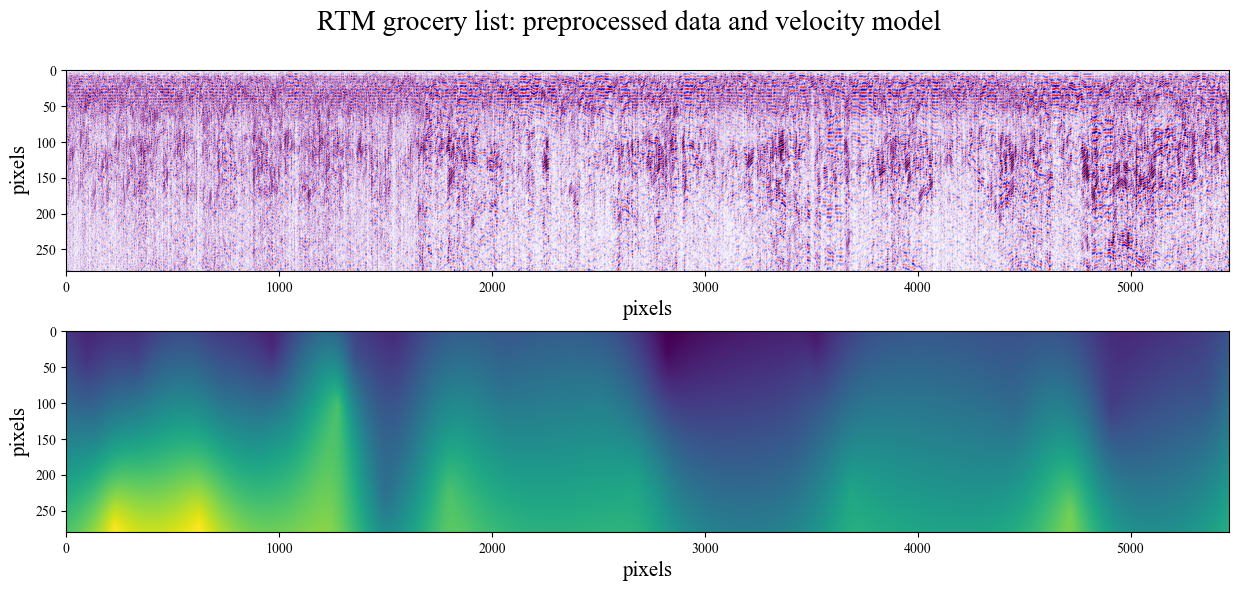

In [1238]:
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 15,
    'axes.titlesize': 20,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.subplot.wspace': 0,  # Example: Increase horizontal spacing
    'figure.subplot.hspace': 0.3,  # Example: Increase vertical spacing
    'figure.figsize': (14, 4) # Adjust figure size
})

p = np.load('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/determining_a_velocity_model/preprocessed_data.npy')
# print(p.shape)
# p = phase_offset_bg[int(200*px_per_ns):, :5551]
min_x, max_x = 0, 1800
min_t, max_t = 0, 700
preprocessed_data, bounds = zoom(p, [min_x, max_x, max_t, min_t])

vel_model = np.load('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/velocity_model.npy')
print(vel_model.max(), vel_model.min())

fig, axs = plt.subplots(2, figsize=(15,6))
fig.suptitle('RTM grocery list: preprocessed data and velocity model', fontsize=20)
axs[0].imshow(preprocessed_data, cmap='seismic', aspect='auto', vmax=preprocessed_data.max()*0.40, vmin=preprocessed_data.min()*0.40)
axs[0].set_ylabel('pixels'), axs[0].set_xlabel('pixels')
axs[1].imshow(vel_model, aspect='auto')
axs[1].set_ylabel('pixels'), axs[1].set_xlabel('pixels')


## Characterizing the source wavelet

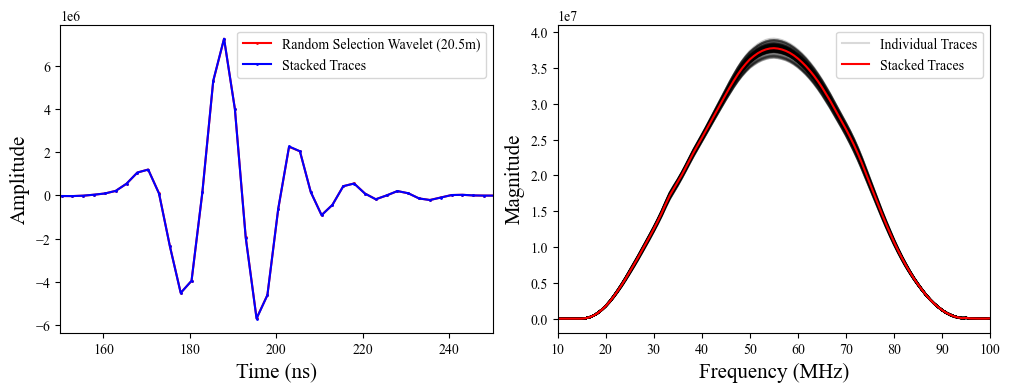

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))
fig.subplots_adjust(wspace=0.15)
'''
time-space
'''
axs[0].set_ylabel('Amplitude'), axs[0].set_xlabel('Time (ns)'), axs[0].set_xlim(150, 250)
random_wavelet = self_detections[:, 20]
stacked_wavelet = np.mean(self_detections, axis=1)
axs[0].plot(np.linspace(0,1200, self_detections.shape[0]), random_wavelet, label='Random Selection Wavelet (20.5m)', c='red', markersize=1)
axs[0].plot(np.linspace(0,1200, self_detections.shape[0]), stacked_wavelet, label='Stacked Traces', c='blue', markersize=1)
axs[0].legend()


'''
Frequency Space. Taking the FT of each trace and averaging them
'''
freq_space_im = []
for i, trace in enumerate(self_detections.T):
    x = np.array(trace)       # your 1D waveform
    n = len(x)
    
    # Sampling interval (seconds)
    dt = 2.5e-9           # 2.5 ns
    
    # FFT
    X = np.fft.fft(x)
    
    # Frequency axis
    freq = np.fft.fftfreq(n, d=dt)

    # Magnitude spectrum
    magnitude = np.abs(X)
    freq_space_im.append(magnitude)
    
    pos_mask = freq >= 0
    axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='black', alpha=0.2, markersize=0)

    

magnitude = np.array(freq_space_im).T.mean(axis=1)
pos_mask = freq >= 0
axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='black', alpha=0.15, markersize=0, label='Individual Traces')
axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='red', markersize=0, label='Stacked Traces'), axs[1].set_xlim(10, 100)
axs[1].set_xlabel('Frequency (MHz)'), axs[1].set_ylabel('Magnitude')
axs[1].legend()

## This looks close enough to a ricker wavelet with peak frequency 55MHz

This is not an eggregious assumption either. When I coresponded with Drs Li Chao and Ling Chen their advice was to begin with this assumption and tweak the source wavelet to adjust for other interference which might skew the distribution slightly as we see above. In my case, becasue I'm using a no-frills RTM --- literally the most basic implementation possible --- I think it's reasonable to assume that any potential decrease the quality of the migrated image imposed by such an ideal wavelet simplification is far smaller than than the limitations of our super simple implementation (which itself is subject to boudary condition and velocty model assumptions, likely to exceede the uncertainty of the wavelet).

## Now begin RTM, select a manegable subsection of the preprocessed section
Here I used 200 pixel (100m) subsections up to 869m, and 200 pixel (50m) subsections past 869m
</br></br>
Also note that the velocity model is resampled to march the shape of the subsection. The velocity model is an interpolated product of the hyperbola fitting so this is another reasonable modification. In most cases, becasue I'm selecting a 200 pixel subsection, the resize operation does nothing to the velocity model anyway.

(280, 200)

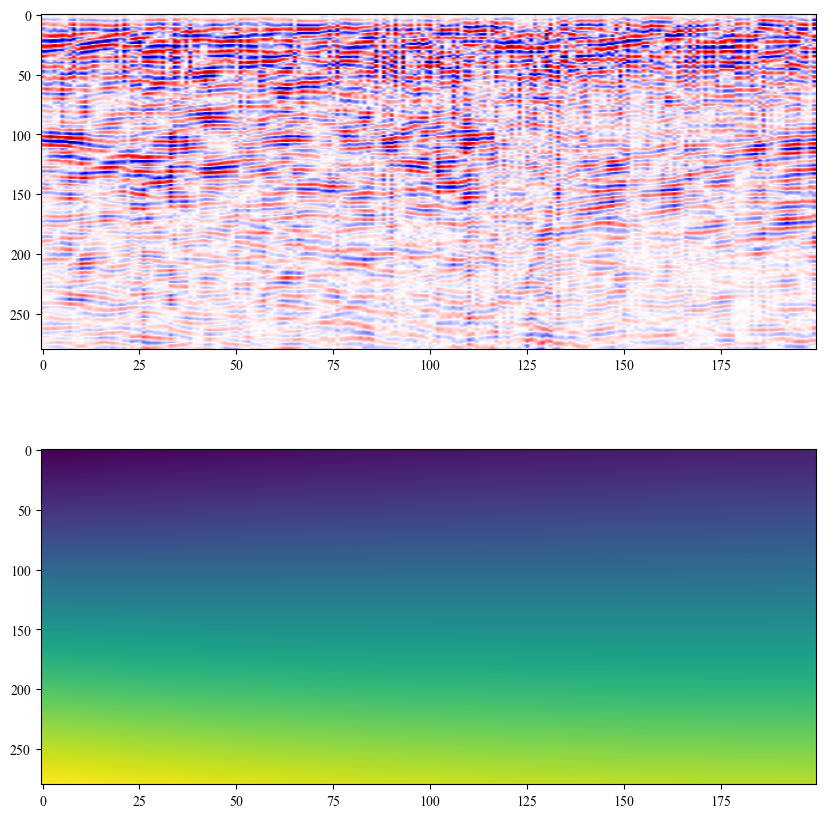

In [764]:
min_x, max_x = 1169, 1219
min_t, max_t = 0, 700
radargram, bounds = zoom(p, [min_x, max_x, max_t, min_t])
eps, _ = zoom(vel_model, [min_x, max_x, max_t, min_t])
eps = resample(eps, 200, axis=1)
cmap = plt.get_cmap('seismic')
rgb_img = cmap(radargram)[:,:,0]
fig, axs = plt.subplots(2, figsize=(10,10))
axs[0].imshow(radargram, cmap="seismic", aspect='auto')
axs[1].imshow(eps, aspect='auto')
radargram.shape

## Constants for RTM

The three big peices that we now have are the velocity model, the preprocessed gpr section, and the wave. We also need:

| Parameter | What is it? |
|---|---|
| dx | The horizontal resolution of the velocity model: how many meters per pixel? |
| dz | The vertical resolution of the velocity model: How many **meters** per pixel. This is an important point to make as the vertical step size up to now has typically been dt. we'll have to estimate dz. Thankfully we already have a function that does this, just modify depth_of_penetration() slightly from its implementation in Quantifying_migration_uncertainty.ipynb|
| dt | how many pixels per ns, this is just 1/px_per_ns defined above |
| shot_positions | A physical parameter. should be np.arange(number of pixels in subsection) * dx|

We need to be careful not violate CFL condition in RTM, so we have to either downsample the velocity model or upsample the raw data. downsampling the velocity model is tempting, but to get something valid at 2.5ns per pixel, we'd have to downsample it to a resolution of around 1m per pixel, this would be catastrophic for rtm as the whole purpose for using a smoothed velocty model is to avoid artificial reflections and interactions between the wavefield and the model itself.
</br></br>
So we must do something we've avoided completely until now, upscaling the preprocessed data. Luckily scipy.signal.resample for periodic data is specifically built to do this in a way that optimally preserves the original features. In order to make this as non-invasive as possible we only resample along the vertical axis --- what makes the most sense for the FFT resample. Why do we use dt = 0.5ns instead of 2.5? As a result of this resampling to 5x the original t axis, we must divide the dt by 5.

## Run RTM

In [765]:
from bruges.filters.wavelets import ricker
from SimulatingGPR import migration as mig
import skimage

c0 = 3e8

from scipy.signal import resample
radargram_upsampled = resample(radargram, 1400, axis=0)  # 280 → 1400 samples to satisfy the cfl condition
'''
Inverse "solution" 3. RTM
'''
data_demeaned = radargram - np.mean(radargram, axis=1, keepdims=True)*0.998

velocity = c0 / np.sqrt(eps.T)
f0 = 5.5e7
dt = 0.5e-9
dz = ((0.3/np.sqrt(np.mean(eps)) * max_t) / 2) / eps.shape[0]
w, _ = ricker(duration=1.5 / f0, dt=dt, f=f0)
w /= np.max(np.abs(w))

'''
just change to 0.25 for past 869 meters
'''
migrated_image_1169_1219 = gpr_rtm(
    radargram=radargram_upsampled,
    shot_positions=np.arange(200) * 0.25,
    velocity_model=velocity,
    dx=0.25,
    dz=dz,
    dt=dt,
    source_wavelet=w
    )


## Saving the result and making sure it looks right

Text(0.5, 1.0, 'Sanity Check, Reloaded Data')

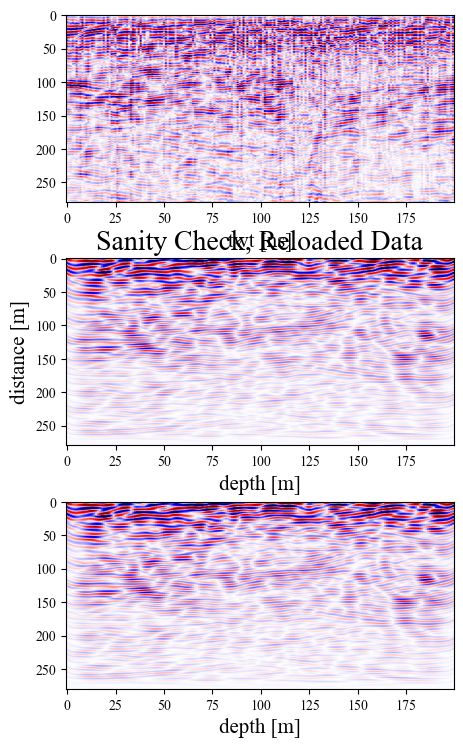

In [767]:
data_demeaned = radargram - np.mean(radargram, axis=1, keepdims=True)*0.998
migrated_data = migrated_image_1169_1219
fname = '1169_1219'
np.save(f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/FWI_products/{fname}.npy', migrated_image_1169_1219)

fig, axs = plt.subplots(3, figsize=(5,8.75))

axs[0].imshow(data_demeaned, aspect='auto', vmin=data_demeaned.min()*0.8, vmax=data_demeaned.max()*0.8, cmap='seismic')
axs[0].set_xlabel("twt [ns]"); axs[1].set_ylabel("distance [m]"); axs[1].set_title('GPR section')

axs[1].imshow(migrated_data.T, aspect='auto', vmin=np.percentile(migrated_data, 0.3), vmax=np.percentile(migrated_data, 99.7), cmap='seismic')
axs[1].set_xlabel("depth [m]"); axs[1].set_ylabel("distance [m]"); axs[1].set_title('Migrated Section (FWI)')

migrated_data_reloaded = np.load(f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/FWI_products/{fname}.npy')
axs[2].imshow(migrated_data_reloaded.T, aspect='auto', vmin=np.percentile(migrated_data_reloaded, 0.3), vmax=np.percentile(migrated_data_reloaded, 99.7), cmap='seismic')
axs[2].set_xlabel("depth [m]"); axs[1].set_ylabel("distance [m]"); axs[1].set_title('Sanity Check, Reloaded Data')


## Kirchhoff is much Simpler, we can use the preprocessed data as is

Also use the mean veloctiy as is the previously published work

In [719]:
tmax = 700e-9
px_per_ns = 0.4
migrated_kirchhoff_1769_1819 = mig.Kichhoff(radargram, np.mean(eps), tmax, int(tmax/((1/px_per_ns)*1e-9)), np.arange(0, tmax, ((1/px_per_ns)*1e-9)), np.arange(0, radargram.shape[1], 1))


## Saving the result and making sure it looks right

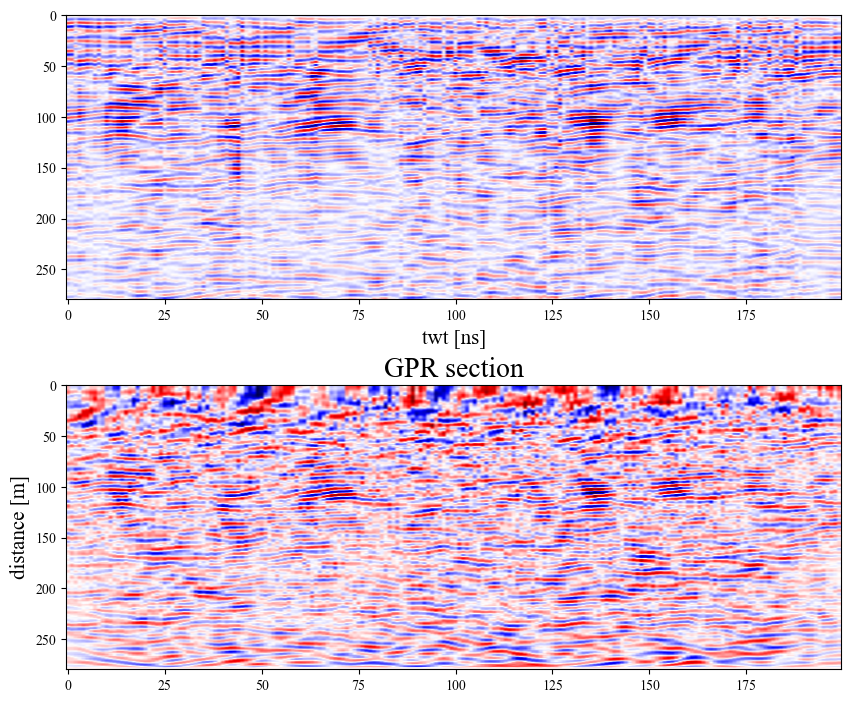

In [721]:
fname = '1769_1819'
np.save(f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/Kirchhoff_products/{fname}.npy', migrated_image_kirchhoff)
m = np.load(f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/Kirchhoff_products/{fname}.npy')
plt.rcParams.update({
    'figure.figsize': (10, 8.5) # Adjust figure size
})
fig, axs = plt.subplots(2)

axs[0].imshow(radargram, aspect='auto', vmin=radargram.min()*0.8, vmax=radargram.max()*0.8, cmap='seismic')
axs[0].set_xlabel("twt [ns]"); axs[1].set_ylabel("distance [m]"); axs[1].set_title('GPR section')
axs[1].imshow(m.T, aspect='auto', vmin=np.percentile(m, 0.01), vmax=np.percentile(m, 99.99), cmap='seismic')


# Stitch together the RTM images

In [1143]:
# Handle Everything up to 869m
intervals = [f'{i*100}_{(i+1)*100}' for i in range(0,8)]
intervals[0] = '000_100'
rtm_file_paths = [f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/FWI_products/{fname}.npy' for fname in intervals] + [f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/FWI_products/800_869.npy']
for i, fname in enumerate(rtm_file_paths):
    if i == 0:
        rtm_image = np.load(fname).T
    else:
        rtm_image = np.concatenate((rtm_image, np.load(fname).T), axis=1)

# Handle everythin past 869m
'''
The only time I will do this:
- Becasue the data is already processed, and I want the whole x axis to have the same dx, I'm going to compress 869m- to dx=0.5
'''
intervals = [f'{val}_{val+50}' for val in [a for a in range(869,1819, 50)]]
rtm_file_paths = [f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/FWI_products/{fname}.npy' for fname in intervals]
for i, fname in enumerate(rtm_file_paths):
    data = np.load(fname).T
    compressed = resample(data, int(data.shape[1]/2), axis=1)
    rtm_image = np.concatenate((rtm_image, compressed), axis=1)

In [1198]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_array_sections(arr, dx, clip_noisy_top):
    """
    Splits a 2D numpy array into 4 equal sections along the n axis
    and plots them as vertically stacked subplots with a shared x-axis in meters.

    Parameters:
        arr : np.ndarray  — shape (m, n)
        dx  : float       — meters per pixel along the n axis
    """
    m, n = arr.shape
    section_size = n // 4
    sections = [arr[clip_noisy_top:, i * section_size:(i + 1) * section_size] for i in range(4)]

    fig, axes = plt.subplots(4, 1, figsize=(11, 8.5), constrained_layout=True)

    for i, (ax, section) in enumerate(zip(axes, sections)):
        x_start = i * section_size * dx
        x_end   = x_start + section.shape[1] * dx
        section = (section-np.mean(section))/(np.std(section))
        depth = depth_of_penetration(vel_model[:, i * section_size:(i + 1) * section_size])
        print(depth)
        im = ax.imshow(
            section,
            aspect="auto",
            extent=[x_start, x_end, depth, 0],  # x in metres, y in rows
            cmap=cmap_diverging_binary,
            origin="upper",
            vmin=np.percentile(section, 0.5),
            vmax=np.percentile(section, 99.5),
        )
        ax.set_ylabel("Depth [m]")
        ax.set_xticks(np.arange(x_start, x_end + 0.1, 50)) # +0.1 to ensure xmax is included
        ax.set_yticks(np.arange(0, depth, 15))
        ax.set_title(f"Section {i + 1}  ({x_start:.2f} – {x_end:.2f} m)", fontsize=9)
        cbar = fig.colorbar(im, ax=ax, pad=0.01)
        cbar.set_label(label='Normalized Signal Amplitude', size=8)

    axes[-1].set_xlabel("Distance [m]")
    fig.suptitle("Reverse Time Migration: Utopia Planitia, Full Section", fontweight="bold")
    plt.show()

In [1253]:
from matplotlib import colors

cs = ["black", "white", "black"]
# Create the colormap
cmap_diverging_binary = colors.LinearSegmentedColormap.from_list(
    "binary_diverging_cmap", cs
)

In [1200]:
def depth_of_penetration(eps):
    velocity_column = 0.3/np.sqrt(np.mean(eps, axis=1))# This is a 1d array where each pixel value is in m/ns
    depth = 0
    ns_per_pixel = 2.5
    for i, pixel in enumerate(velocity_column):
        depth+=(ns_per_pixel*pixel)
    return depth/2

46.78348744530334
47.186905269861604
47.09675206047592
53.6542698528834


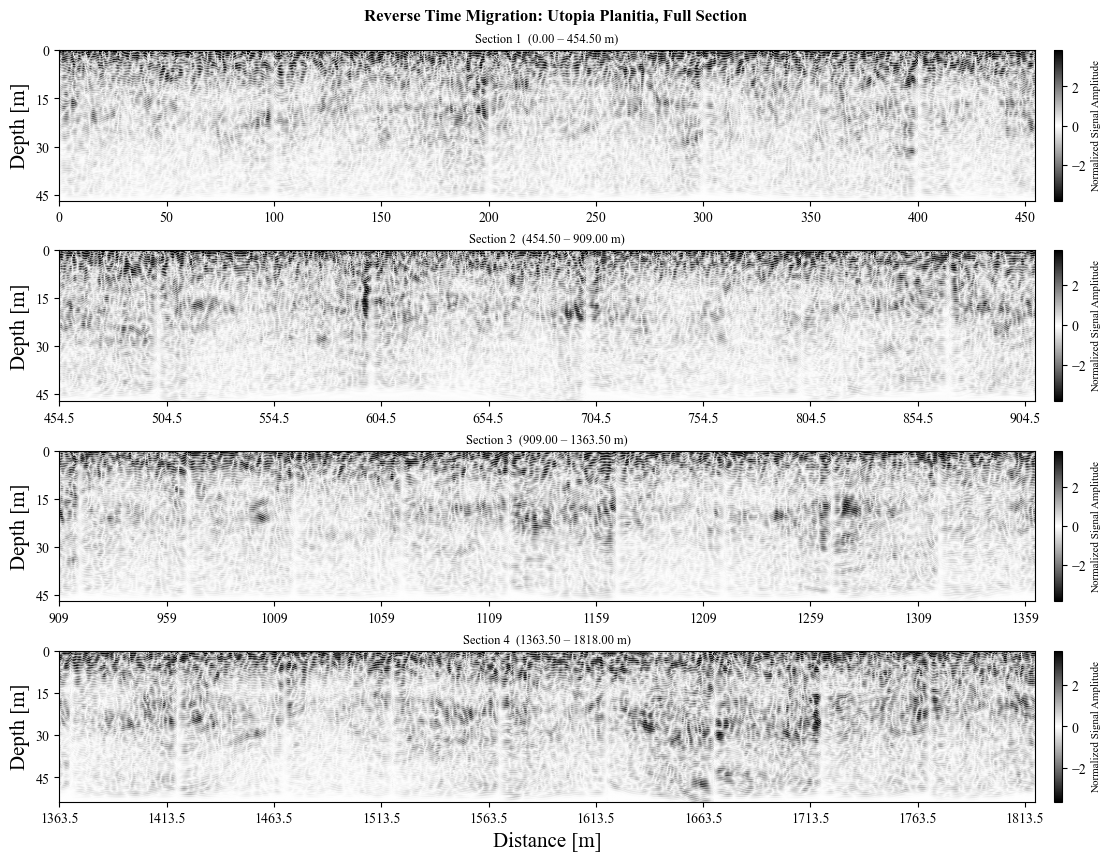

In [1201]:
plot_array_sections(rtm_image, dx=0.5, clip_noisy_top=0)

# Stitch together the Kirchhoff images

In [1167]:
# Handle Everything up to 869m
intervals = [f'{i*100}_{(i+1)*100}' for i in range(0,8)]
intervals[0] = '000_100'
print(intervals)
Kirchhoff_file_paths = [f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/Kirchhoff_products/{fname}.npy' for fname in intervals] + [f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/Kirchhoff_products/800_869.npy']

for i, fname in enumerate(Kirchhoff_file_paths):
    if i == 0:
        Kirchhoff_image = np.load(fname).T
    else:
        Kirchhoff_image = np.concatenate((Kirchhoff_image, np.load(fname).T), axis=1)

# Handle everythin past 869m
'''
The only time I will do this:
- Becasue the data is already processed, and I want the whole x axis to have the same dx, I'm going to compress 869m- to dx=0.5
'''
intervals = [f'{val}_{val+50}' for val in [a for a in range(869,1819, 50)]]
intervals = Kirchhoff_file_paths = [f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/Kirchhoff_products/{fname}.npy' for fname in intervals]
for i, fname in enumerate(Kirchhoff_file_paths):
    data = np.load(fname).T
    compressed = resample(data, int(data.shape[1]/2), axis=1)
    Kirchhoff_image = np.concatenate((Kirchhoff_image, compressed), axis=1)

['000_100', '100_200', '200_300', '300_400', '400_500', '500_600', '600_700', '700_800']


In [1192]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_array_sections(arr, dx, clip_noisy_top):
    """
    Splits a 2D numpy array into 4 equal sections along the n axis
    and plots them as vertically stacked subplots with a shared x-axis in meters.

    Parameters:
        arr : np.ndarray  — shape (m, n)
        dx  : float       — meters per pixel along the n axis
    """
    m, n = arr.shape
    section_size = n // 4
    sections = [arr[clip_noisy_top:, i * section_size:(i + 1) * section_size] for i in range(4)]

    fig, axes = plt.subplots(4, 1, figsize=(11, 8.5), constrained_layout=True)

    for i, (ax, section) in enumerate(zip(axes, sections)):
        x_start = i * section_size * dx
        x_end   = x_start + section.shape[1] * dx
        section = (section-np.mean(section))/np.std(section)
        top, depth = depth_of_penetration(vel_model[:, i * section_size:(i + 1) * section_size], clip_noisy_top)
        im = ax.imshow(
            section,
            aspect="auto",
            extent=[x_start, x_end, depth, top],  # x in metres, y in rows
            cmap=cmap_diverging_binary,
            origin="upper",
            vmin=np.percentile(section, 0.3)*1.3,
            vmax=np.percentile(section, 99.7)*1.3,
        )
        ax.set_ylabel("Depth [m]")
        ax.set_xticks(np.arange(x_start, x_end + 0.1, 50)) # +0.1 to ensure xmax is included
        ax.set_yticks(np.arange(top, depth+0.1, 15).astype(int))
        ax.set_title(f"Section {i + 1}  ({x_start:.2f} – {x_end:.2f} m)", fontsize=9)
        cbar = fig.colorbar(im, ax=ax, pad=0.01)
        cbar.set_label(label='Normalized Signal Amplitude', size=8)

    axes[-1].set_xlabel("Distance [m]")
    fig.suptitle("Kirchhoff Migration: Utopia Planitia, Full Section", fontweight="bold")
    plt.show()

In [1193]:
def depth_of_penetration(eps, clip_noisy_top):
    velocity = 0.3/np.sqrt(np.mean(eps))# This is a 1d array where each pixel value is in m/ns
    ns_per_pixel = 2.5
    depth = (eps.shape[0]*ns_per_pixel)*velocity
    noisy_top_depth = (clip_noisy_top*ns_per_pixel)*velocity
    bottom = depth/2
    top = (noisy_top_depth/2)
    print(top, bottom)
    return top, bottom

8.170570721794405 45.755196042048674
8.343382947653026 46.722944506856955
8.354879431647673 46.78732481722697
9.462761956982856 52.991466959103995


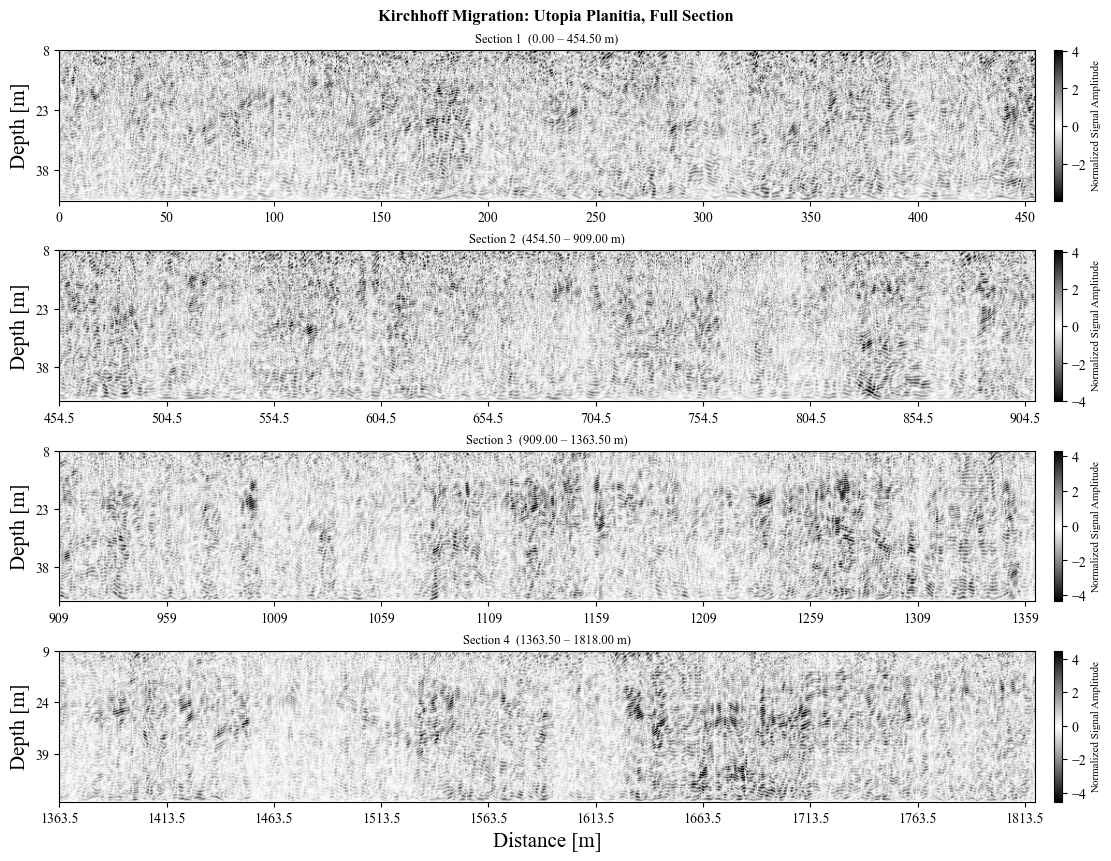

In [1194]:
plot_array_sections(Kirchhoff_image, dx=0.5, clip_noisy_top=50)

# Stitch together the F-K images

F-K is so fast we don't even have to break the data up into subsections, just for when the dx changes

In [1257]:
Dmig1, tmig, xmig = mig.fkmig(preprocessed_data[:, :1738], dt=2.5, dx=0.5, v=0.3/np.sqrt(np.mean(eps)), params=None)
np.save("/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/FK_products/0_869", Dmig1)
Dmig1.shape

(280, 1738)

In [1258]:
Dmig2, tmig, xmig = mig.fkmig(preprocessed_data[:, 1738:], dt=0.4, dx=0.25, v=0.3/np.sqrt(np.mean(eps)), params=None)
np.save("/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/FK_products/869_1819", Dmig2)
Dmig2.shape

(280, 3723)

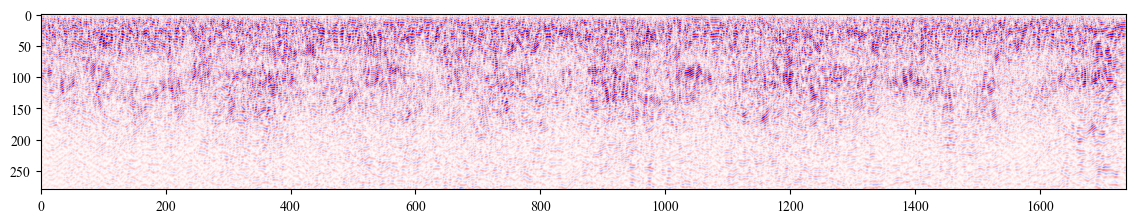

In [1259]:
plt.imshow(Dmig1, cmap='seismic')

In [1280]:
FK_file_paths = ['/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/FK_products/0_869.npy', '/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/FK_products/869_1819.npy']

for i, fname in enumerate(FK_file_paths):
    if i == 0:
        FK_image = np.load(fname)
    else:
        data = np.load(fname)
        FK_image = np.concatenate((FK_image, resample(data, int(data.shape[1]/2), axis=1)), axis=1)

In [1286]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_array_sections(arr, dx, clip_noisy_top):
    """
    Splits a 2D numpy array into 4 equal sections along the n axis
    and plots them as vertically stacked subplots with a shared x-axis in meters.

    Parameters:
        arr : np.ndarray  — shape (m, n)
        dx  : float       — meters per pixel along the n axis
    """
    m, n = arr.shape
    section_size = n // 4
    sections = [arr[clip_noisy_top:, i * section_size:(i + 1) * section_size] for i in range(4)]

    fig, axes = plt.subplots(4, 1, figsize=(11, 8.5), constrained_layout=True)

    for i, (ax, section) in enumerate(zip(axes, sections)):
        x_start = i * section_size * dx
        x_end   = x_start + section.shape[1] * dx
        section = (section-np.mean(section))/np.std(section)
        top, depth = depth_of_penetration(vel_model[:, i * section_size:(i + 1) * section_size], clip_noisy_top)
        im = ax.imshow(
            section,
            aspect="auto",
            extent=[x_start, x_end, depth, top],  # x in metres, y in rows
            cmap=cmap_diverging_binary,
            origin="upper",
            vmin=np.percentile(section, 0.3)*1.3,
            vmax=np.percentile(section, 99.7)*1.3,
        )
        ax.set_ylabel("Depth [m]")
        ax.set_xticks(np.arange(x_start, x_end + 0.1, 50)) # +0.1 to ensure xmax is included
        ax.set_yticks(np.arange(top, depth+0.1, 15).astype(int))
        ax.set_title(f"Section {i + 1}  ({x_start:.2f} – {x_end:.2f} m)", fontsize=9)
        cbar = fig.colorbar(im, ax=ax, pad=0.01)
        cbar.set_label(label='Normalized Signal Amplitude', size=8)

    axes[-1].set_xlabel("Distance [m]")
    fig.suptitle("F-K Migration: Utopia Planitia, Full Section", fontweight="bold")
    plt.show()

In [1287]:
def depth_of_penetration(eps, clip_noisy_top):
    velocity = 0.3/np.sqrt(np.mean(eps))# This is a 1d array where each pixel value is in m/ns
    ns_per_pixel = 2.5
    depth = (eps.shape[0]*ns_per_pixel)*velocity
    noisy_top_depth = (clip_noisy_top*ns_per_pixel)*velocity
    bottom = depth/2
    top = (noisy_top_depth/2)
    print(top, bottom)
    return top, bottom

0.0 45.7395132911219
0.0 46.76435383657821
0.0 46.68280745116427
0.0 53.012868974059415


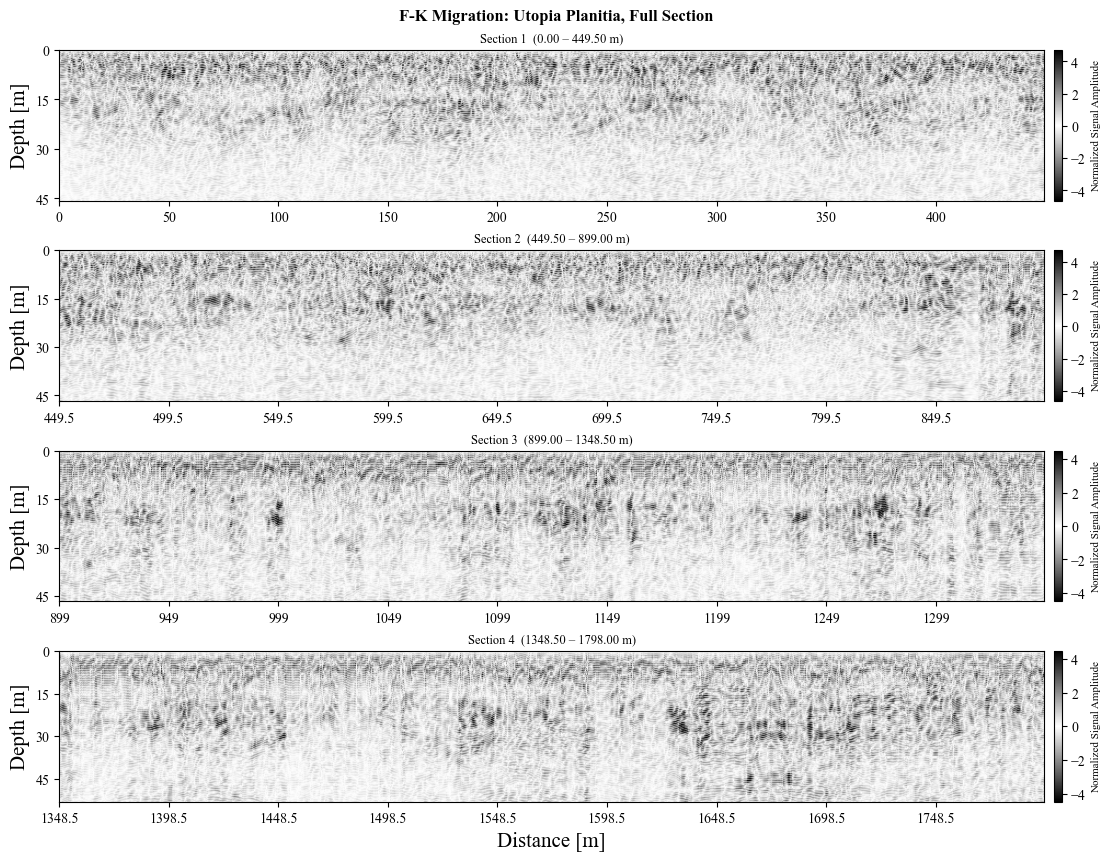

In [1288]:
plot_array_sections(FK_image, dx=0.5, clip_noisy_top=0)

In [1304]:
dz = 0.4
dx = 0.5
(0.3/np.sqrt(np.max(vel_model))) * 2.5 * np.sqrt(1/0.5**2 + 1/dz**2)

1.0738365797457263